# gEval entity classification

The **supervised** GEval task (Pellegrino et al.; MASCHInE §4.2): use each
entity's embedding as features to predict a categorical label, scored by
**accuracy** under 10-fold stratified CV. Complements the unsupervised
clustering view in [`geval_clustering.ipynb`](geval_clustering.ipynb).

| dataset | entity type | label |
|---|---|---|
| **Cities** | cities | quality-of-living class (high/medium/low) |
| **AAUP** | universities | salary class |
| **Forbes** | companies | revenue class |
| **MetacriticAlbums** | albums | critic-score class (good/bad) |
| **MetacriticMovies** | movies | critic-score class (good/bad) |

**Classifier panel** (GEval-style): Naive Bayes, k-NN (k=3), C4.5 decision
tree, linear SVM. We report mean CV accuracy per classifier plus their average.
Only entities present in the shared 1.28M-key vocab are usable (the rest are
GEval's *ignored data*); classes too small to stratify are dropped.

Gold files: `evaluation_framework/Classification/data/*.tsv` → `v1/geval/classification/`.
Logic: [`scripts/_geval.py`](../scripts/_geval.py).

In [1]:
import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scripts import _geval
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
OUT = REPO / "notebooks" / "geval_classification"; OUT.mkdir(exist_ok=True)
DATASETS = ["Cities", "AAUP", "Forbes", "MetacriticAlbums", "MetacriticMovies"]
# Bound family: only the norm-capped (cap16) variants are used; the no-cap
# p{1,2,3}_bound are excluded from every gEval experiment.
ORDER = ["vanilla", "p1_classic", "p2_classic", "p3_classic",
         "p2_bound_cap16", "p3_bound_cap16"]
print("datasets:", DATASETS, "| classifiers:", list(_geval.CLASSIFIERS))

datasets: ['Cities', 'AAUP', 'Forbes', 'MetacriticAlbums', 'MetacriticMovies'] | classifiers: ['NB', 'KNN', 'C4.5', 'SVM']


## 1. Coverage (per dataset, shared vocab)

How many gold entities exist in our embedding vocab. All variants share one
vocab, so coverage is identical across variants — checked once.

In [2]:
vocab = _geval.load_vocab("vanilla")
cov = {ds: (_geval.classification_coverage(ds, vocab)
              .set_index("label")["coverage"]) for ds in DATASETS}
pd.DataFrame(cov)

,Cities,AAUP,Forbes,MetacriticAlbums,MetacriticMovies
label,,,,,
ALL,0.868,0.796,0.250,0.358,0.539
bad,NaN,NaN,NaN,0.431,0.531
good,NaN,NaN,NaN,0.285,0.548
high,0.910,0.944,0.636,NaN,NaN
low,0.821,0.606,0.176,NaN,NaN
medium,0.858,0.825,0.287,NaN,NaN


## 2. Classification per dataset — 10-fold CV accuracy, raw vectors

One row per variant; columns are the classifier panel + their `mean`. `n` =
entities used after coverage + stratifiability filtering.

In [3]:
results = {ds: _geval.evaluate_classification(ds, variants=ORDER) for ds in DATASETS}
for ds in DATASETS:
    print(f"\n===== {ds} =====")
    print(results[ds].reindex(ORDER)[list(_geval.CLASSIFIERS)+["mean","n"]].to_string())


===== Cities =====
                  NB   KNN  C4.5   SVM  mean       n
vanilla        0.781 0.656 0.527 0.765 0.682 184.000
p1_classic     0.684 0.646 0.516 0.701 0.637 184.000
p2_classic     0.695 0.668 0.653 0.749 0.691 184.000
p3_classic     0.656 0.673 0.558 0.706 0.648 184.000
p2_bound_cap16 0.554 0.662 0.536 0.732 0.621 184.000
p3_bound_cap16 0.505 0.640 0.598 0.706 0.612 184.000

===== AAUP =====
                  NB   KNN  C4.5   SVM  mean       n
vanilla        0.543 0.547 0.544 0.630 0.566 764.000
p1_classic     0.420 0.611 0.555 0.677 0.566 764.000
p2_classic     0.480 0.617 0.512 0.683 0.573 764.000
p3_classic     0.480 0.581 0.550 0.664 0.569 764.000
p2_bound_cap16 0.628 0.631 0.614 0.682 0.639 764.000
p3_bound_cap16 0.595 0.590 0.564 0.682 0.608 764.000

===== Forbes =====
                  NB   KNN  C4.5   SVM  mean       n
vanilla        0.402 0.462 0.437 0.561 0.465 396.000
p1_classic     0.326 0.475 0.447 0.558 0.451 396.000
p2_classic     0.361 0.467 0.434 0.573 0.

## 3. Summary — mean accuracy by variant × dataset (the money table)

In [4]:
acc = pd.DataFrame({ds: results[ds]["mean"] for ds in DATASETS}).reindex(ORDER)
acc.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1, axis=None).format("{:.3f}")

,Cities,AAUP,Forbes,MetacriticAlbums,MetacriticMovies
vanilla,0.682,0.566,0.465,0.565,0.657
p1_classic,0.637,0.566,0.451,0.569,0.615
p2_classic,0.691,0.573,0.459,0.563,0.631
p3_classic,0.648,0.569,0.471,0.578,0.623
p2_bound_cap16,0.621,0.639,0.489,0.562,0.642
p3_bound_cap16,0.612,0.608,0.479,0.560,0.643


## 4. Grouped bar — mean accuracy by variant × dataset

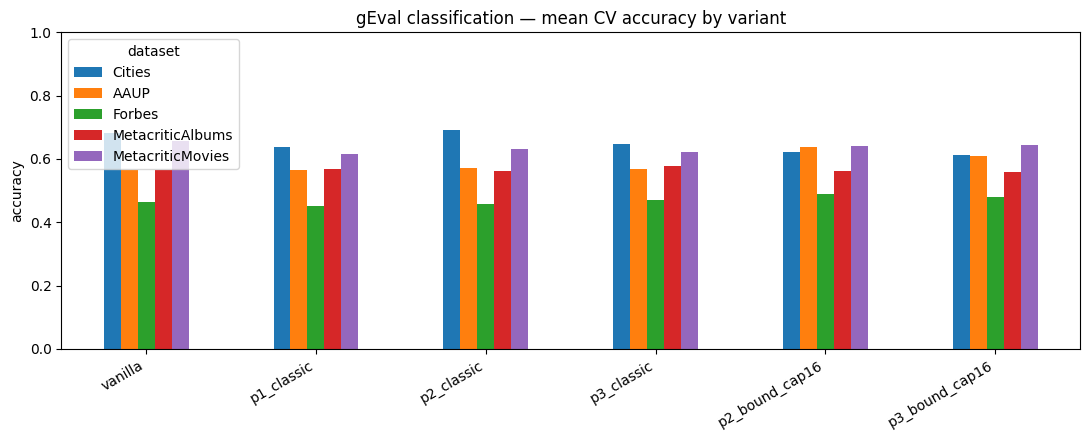

In [5]:
ax = acc.plot.bar(figsize=(11, 4.5))
ax.set_title("gEval classification — mean CV accuracy by variant")
ax.set_ylabel("accuracy"); ax.set_ylim(0, 1)
ax.legend(title="dataset"); plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.savefig(OUT / "geval_acc_by_variant.png", dpi=120); plt.show()

## Takeaways

Classification tells a **very different story from clustering** — and that contrast
is the result.

- **Supervised classification flattens the variants.** Mean accuracy sits in a
  narrow band (≈0.46–0.69) and no variant dominates: the huge `*_classic ≫ vanilla`
  gap that defined clustering (CC: 0.72 vs 0.06) is *gone*. A fitted decision
  boundary (NB/KNN/C4.5/SVM) extracts class signal that raw k-means geometry could
  not, so the init's head start matters far less.
- **`vanilla` is competitive — even best on some datasets** (Cities 0.682,
  MetacriticMovies 0.657). Concept init no longer buys a consistent edge once a
  classifier does the separating.
- **The capped bound, which *collapses* on clustering, is competitive here.**
  `*_bound_cap16` is the **best** variant on AAUP (0.639) and Forbes (0.489), and on
  MetacriticMovies it has the single best classifier (SVM 0.737 vs vanilla 0.689)
  though vanilla edges it on the mean. The geometry the bound init produces is
  hostile to k-means but perfectly usable by a supervised model — a clean
  illustration that "good embedding" is task-relative.
- **`*_classic` only marginally leads where labels track ontology class** (Cities
  0.691 via p2, AAUP 0.573). Where labels are critic scores / revenue (weakly tied
  to schema) it has no advantage, and on MetacriticMovies it is the *worst* family.
- **Takeaway for the thesis.** Clustering and classification probe different things:
  clustering rewards init geometry; classification rewards separability a model can
  fit. The schema-init story is strong on the former and washes out on the latter —
  report both so the claim is scoped, not overstated.